## CCBD Project 6 — Cloud Bill Estimator: Analysis
### **Variant 6**: Cost ("cloud bill") estimator for S3 object storage.
### This notebook analyses results.csv produced by bench.py and provides cost breakdowns, performance comparisons, and concrete recommendations.

In [1]:
# imports and reading data
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
df = pd.read_csv('results.csv')


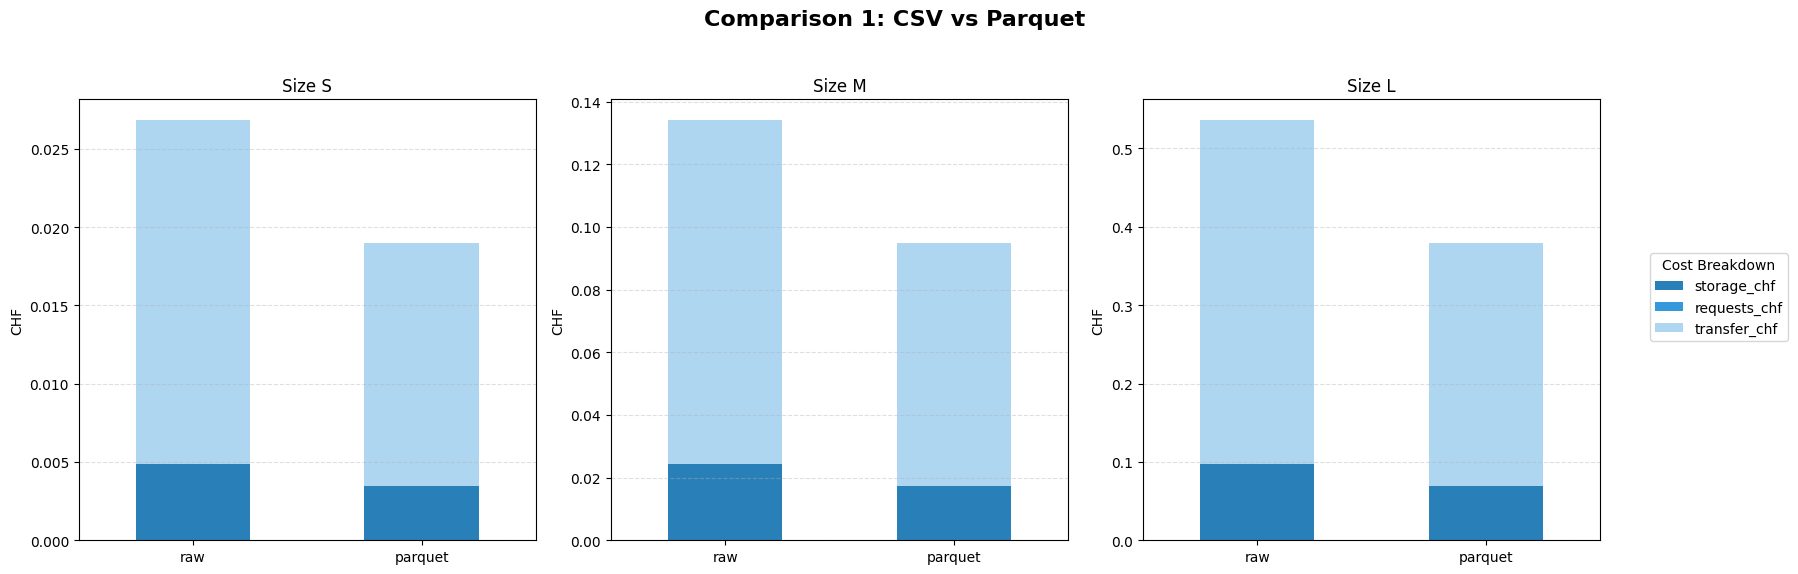

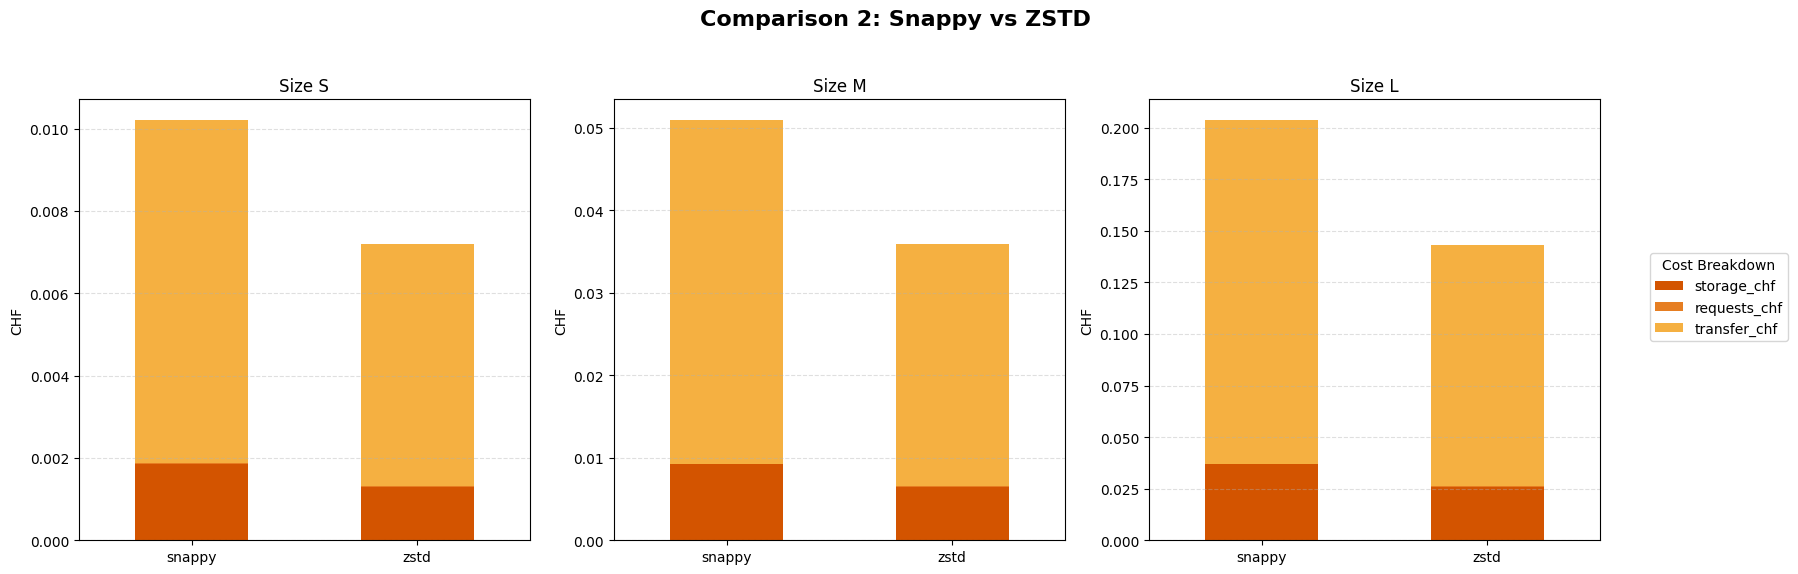

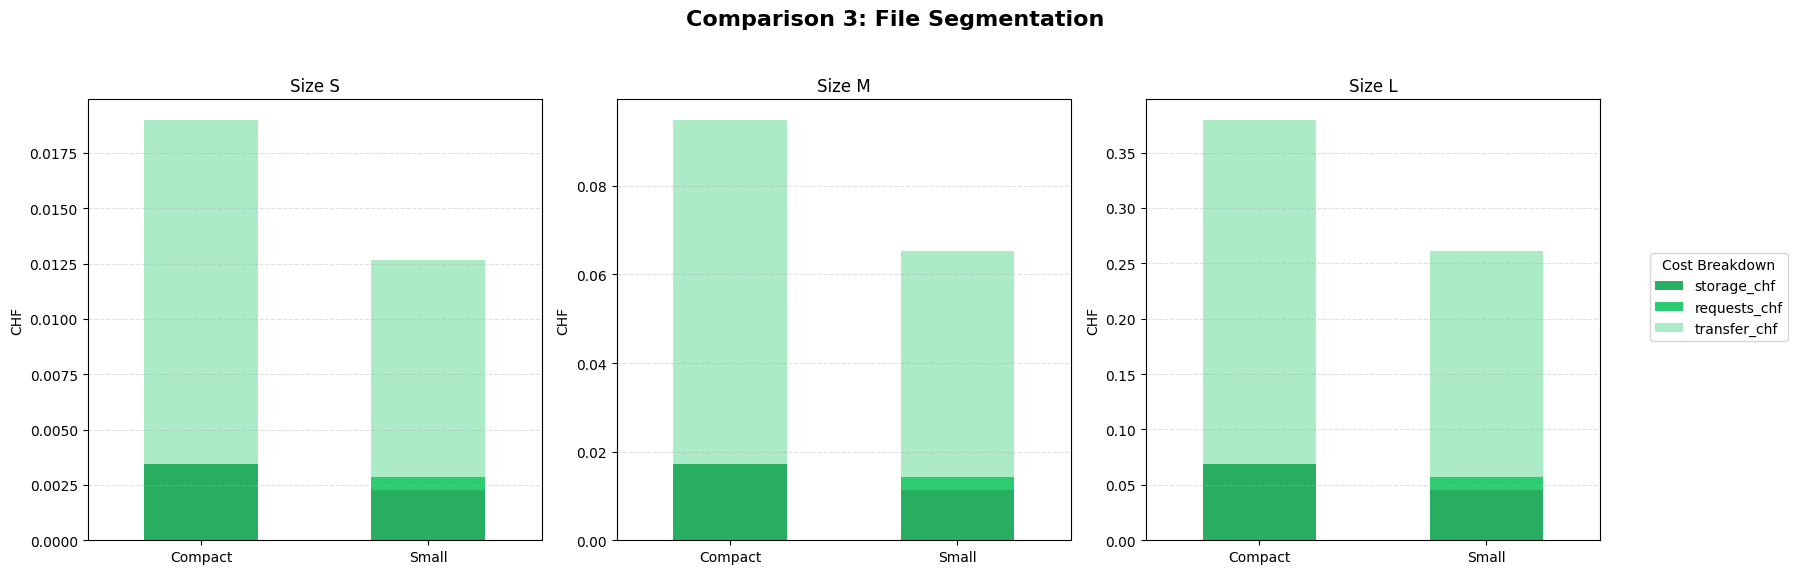

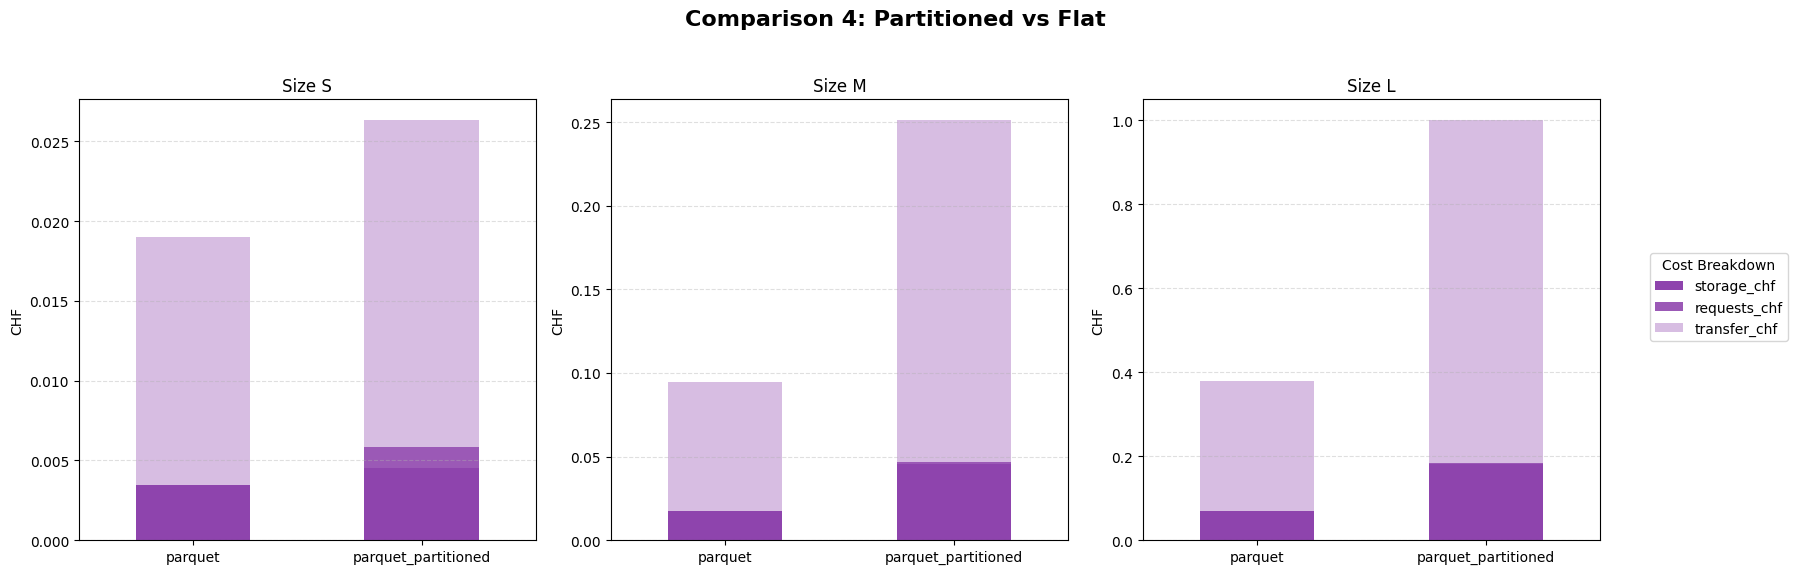

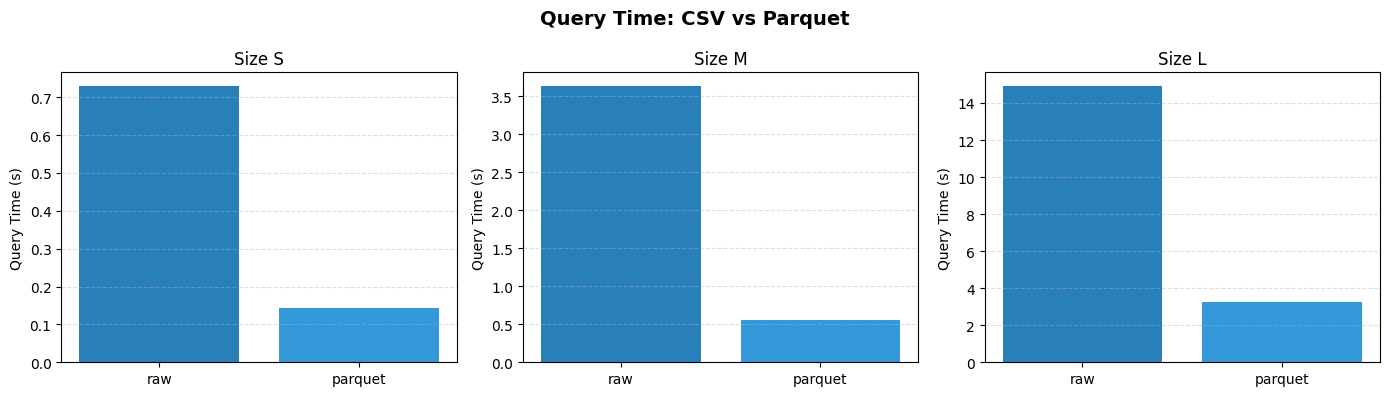

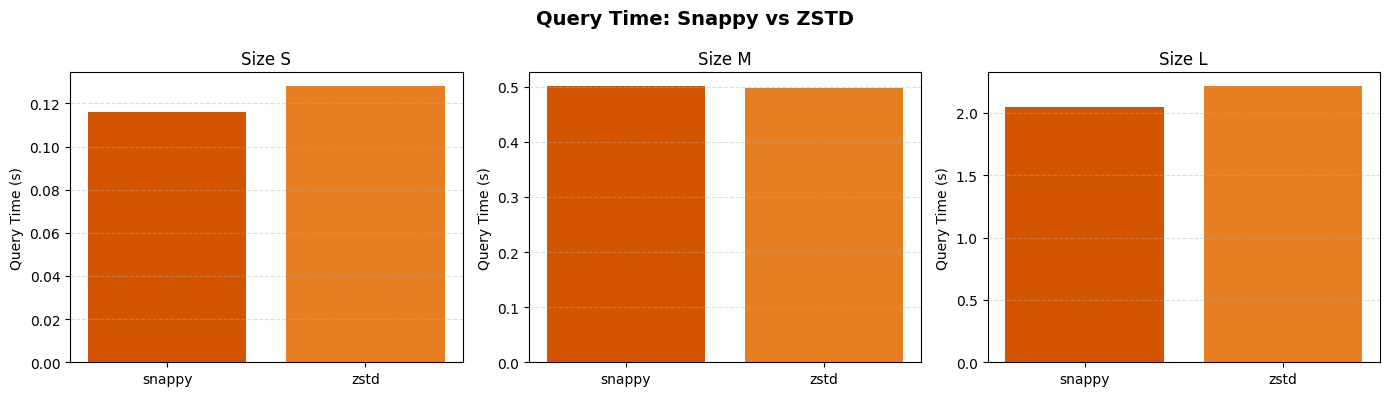

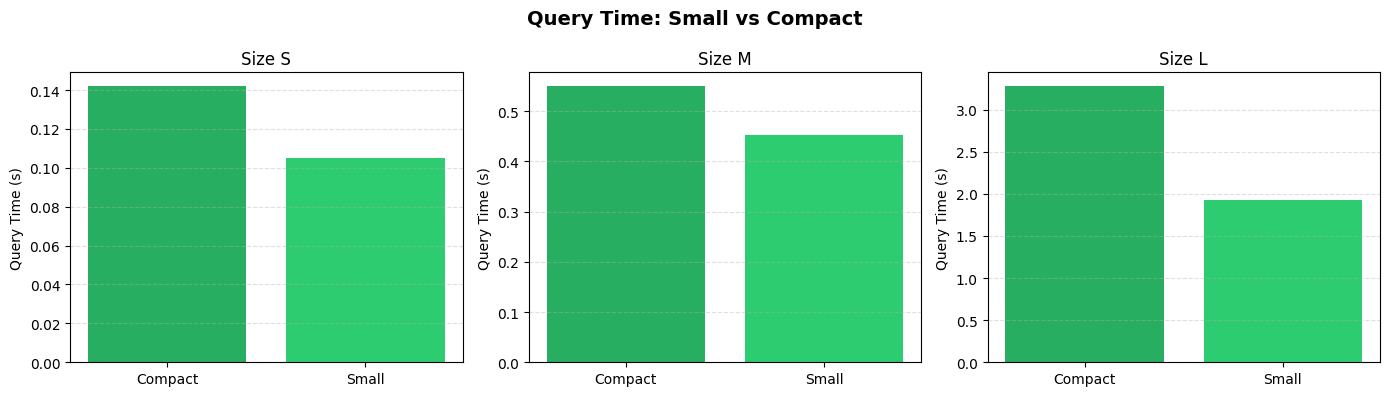

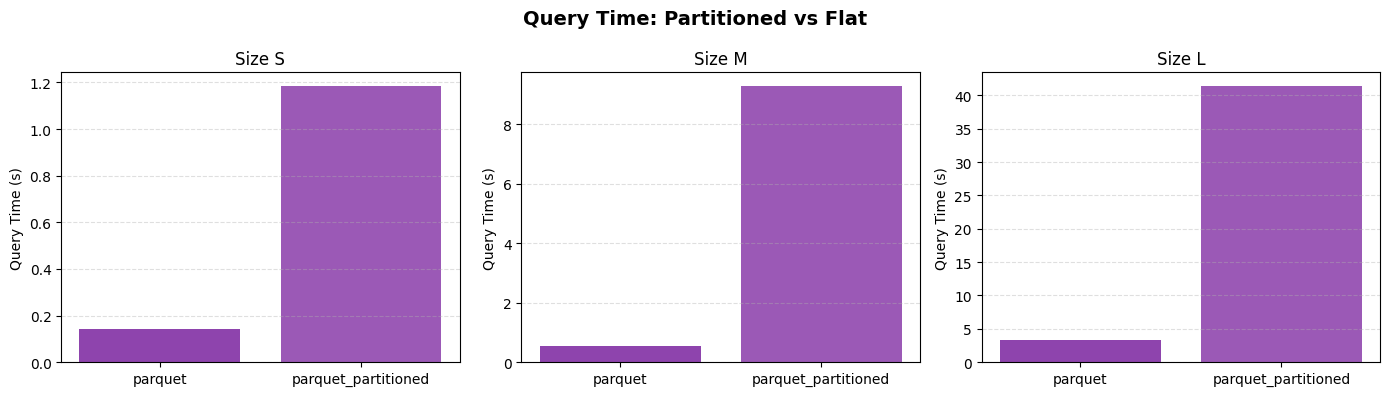

label             variant compression  stored_mb  compression_ratio  savings_pct
    L             parquet        zstd    1303.21               3.74         73.2
    L             parquet      snappy    1850.39               2.63         62.0
    L       parquet_small         NaN    2263.50               2.15         53.5
    L             parquet        none    3445.75               1.41         29.3
    L                 raw         NaN    4871.65               1.00          0.0
    L parquet_partitioned         NaN    9081.47               0.54        -86.4
    M             parquet        zstd     325.81               3.74         73.2
    M             parquet      snappy     462.60               2.63         62.0
    M       parquet_small         NaN     565.86               2.15         53.5
    M             parquet        none     861.44               1.41         29.3
    M                 raw         NaN    1217.91               1.00          0.0
    M parquet_partitioned   

In [ ]:

SIZES = ['S', 'M', 'L']
COST_COLS = ['storage_chf', 'requests_chf', 'transfer_chf']

def plot_cost(df, filter_fn, x_col, title, palette):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
    fig.suptitle(title, fontsize=16, fontweight='bold')

    for i, size in enumerate(SIZES):
        subset = filter_fn(df[df['label'] == size].copy())
        if not subset.empty:
            subset.set_index(x_col)[COST_COLS].plot(
                kind='bar', stacked=True, ax=axes[i], color=palette, legend=False
            )
            axes[i].set_title(f'Size {size}', fontsize=12)
            axes[i].set_ylabel('CHF')
            axes[i].set_xlabel('')
            axes[i].tick_params(axis='x', rotation=0)
            axes[i].grid(axis='y', linestyle='--', alpha=0.4)
        else:
            axes[i].set_title(f'Size {size} (No Data)')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Cost Breakdown', loc='center right', bbox_to_anchor=(1, 0.5))
    plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])
    plt.show()

def filter_format(d):
    return d[
        (d['n_files'] == 1) &
        ((d['variant'] == 'raw') | ((d['variant'] == 'parquet') & (d['compression'] == 'none')))
    ]

def filter_compression(d):
    return d[
        (d['variant'] == 'parquet') &
        d['compression'].notna() &
        (d['compression'] != 'none')
    ]

def filter_segmentation(d):
    sub = d[
        ((d['variant'] == 'parquet') & (d['compression'] == 'none')) |
        (d['variant'] == 'parquet_small')
    ].copy()
    sub['sizing'] = sub['n_files'].apply(lambda x: 'Small' if x > 1 else 'Compact')
    return sub

def filter_partition(d):
    return d[
        ((d['variant'] == 'parquet') & (d['compression'] == 'none')) |
        (d['variant'] == 'parquet_partitioned')
    ]

# i wanna show the query time for the different design choices too, gives good insights
def plot_query_time(df, filter_fn, x_col, title, palette):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i, size in enumerate(SIZES):
        subset = filter_fn(df[df['label'] == size].copy())
        if not subset.empty:
            subset = subset.set_index(x_col)
            axes[i].bar(subset.index, subset['query_time_s'], color=palette)
            axes[i].set_title(f'Size {size}')
            axes[i].set_ylabel('Query Time (s)')
            axes[i].grid(axis='y', linestyle='--', alpha=0.4)
            axes[i].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()


# keeping it consistent
blue_palette   = ['#2980b9', '#3498db', '#aed6f1']
orange_palette = ['#d35400', '#e67e22', '#f5b041']
green_palette  = ['#27ae60', '#2ecc71', '#abebc6']
purple_palette = ['#8e44ad', '#9b59b6', '#d7bde2']

plot_cost(df,filter_format,'variant','Comparison 1: CSV vs Parquet',blue_palette)
plot_cost(df,filter_compression, 'compression','Comparison 2: Snappy vs ZSTD',orange_palette)
plot_cost(df,filter_segmentation,'sizing','Comparison 3: File Segmentation',green_palette)
plot_cost(df,filter_partition,   'variant','Comparison 4: Partitioned vs Flat',purple_palette)

plot_query_time(df,filter_format,'variant','Query Time: CSV vs Parquet',blue_palette)
plot_query_time(df,filter_compression,'compression','Query Time: Snappy vs ZSTD',orange_palette)
plot_query_time(df,filter_segmentation,'sizing','Query Time: Small vs Compact',green_palette)
plot_query_time(df,filter_partition,'variant','Query Time: Partitioned vs Flat',purple_palette)

raw_mb = df[df['variant'] == 'raw'].set_index('label')['stored_mb']
df['savings_pct'] = df.apply(
    lambda r: round((1 - r['stored_mb'] / raw_mb[r['label']]) * 100, 1), axis=1
)
df['compression_ratio'] = df.apply(
    lambda r: round(raw_mb[r['label']] / r['stored_mb'], 2), axis=1
)

print(df[['label', 'variant', 'compression', 'stored_mb', 'compression_ratio', 'savings_pct']]
      .sort_values(['label', 'compression_ratio'], ascending=[True, False])
      .to_string(index=False))


In [17]:
df['transfer_pct']  = (df['transfer_chf']  / df['total_chf'] * 100).round(1)
df['requests_pct']  = (df['requests_chf']  / df['total_chf'] * 100).round(1)
df['storage_pct']   = (df['storage_chf']   / df['total_chf'] * 100).round(1)

print(df[['label', 'variant', 'compression', 'storage_pct', 'requests_pct', 'transfer_pct', 'total_chf']]
      .sort_values('total_chf')
      .to_string(index=False))

label             variant compression  storage_pct  requests_pct  transfer_pct  total_chf
    S             parquet        zstd         18.1           0.3          81.6   0.007190
    S             parquet      snappy         18.1           0.2          81.6   0.010199
    S       parquet_small         NaN         17.9           4.8          77.3   0.012652
    S             parquet        none         18.2           0.1          81.7   0.018974
    S parquet_partitioned         NaN         17.3           5.0          77.7   0.026312
    S                 raw         NaN         18.2           0.1          81.8   0.026817
    M             parquet        zstd         18.2           0.1          81.8   0.035861
    M             parquet      snappy         18.2           0.0          81.8   0.050908
    M       parquet_small         NaN         17.3           4.6          78.0   0.065255
    M             parquet        none         18.2           0.0          81.8   0.094780
    M     

Transfer (egress) accounts for >80% of total cost at all sizes and variants. Storage is secondary (~18%). Requests are negligible (<2%) except for parquet_partitioned, where 60 LIST operations push requests to ~0.5%. The dominant cost lever is therefore compression — anything that reduces bytes transferred directly reduces the bill.


### Anomaly: parquet_partitioned inflates storage

At size M, parquet_partitioned stores 2270 MB — nearly 2× more than raw CSV (1217 MB). At L it stores 9081 MB vs 4871 MB raw. This is because 120 Hive partition folders each contain separate row-group footer metadata, duplicating schema and statistics overhead across every file. Combined with 60 LIST requests (one per partition prefix), this variant is both the most expensive and the slowest at query time (41s at L vs 2s for parquet_zstd).

## Query Performance (predicate pushdown scan time)
All variants run the same filter: region=Europe, ts in [2022-01-01, 2023-01-01], groupby event_type

Despite being partitioned by date, parquet_partitioned is the *slowest* variant at M (9.3s) and L (41.4s), because 120 small partition files create a high amount of open/close.

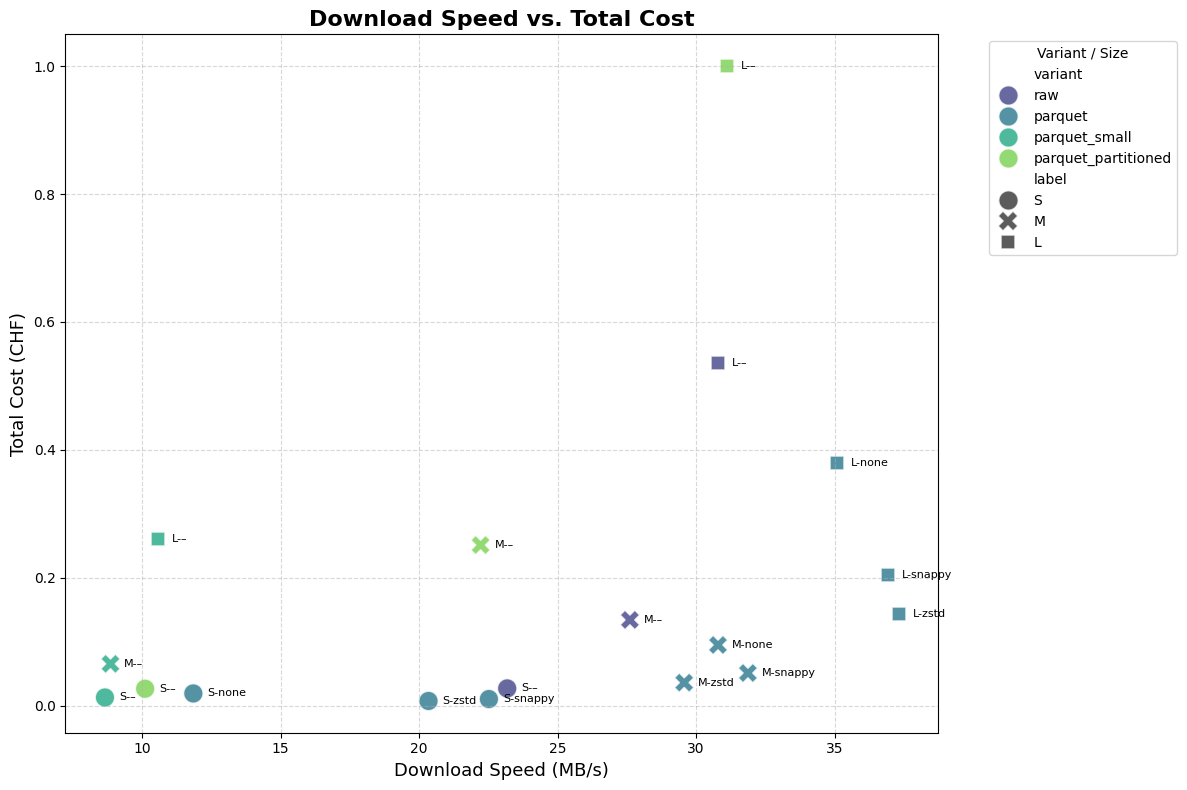

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x='dl_mbps',
    y='total_chf',
    hue='variant',
    style='label',
    s=200,
    alpha=0.8,
    palette='viridis',
    ax=ax
)

ax.set_title('Download Speed vs. Total Cost', fontsize=16, fontweight='bold')
ax.set_xlabel('Download Speed (MB/s)', fontsize=13)
ax.set_ylabel('Total Cost (CHF)', fontsize=13)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Variant / Size', bbox_to_anchor=(1.05, 1), loc='upper left')

for i in range(df.shape[0]):
    label = f"{df.label.iloc[i]}-{df.compression.fillna('–').iloc[i]}"
    ax.text(df.dl_mbps.iloc[i] + 0.5, df.total_chf.iloc[i], label, fontsize=8, va='center')

plt.tight_layout()
plt.show()

The scatter plot reveals two clear clusters. Compressed single-file variants
(`parquet_snappy`, `parquet_zstd`) occupy the bottom-right — high download speed
with low cost — making them the optimal choice. Uncompressed and partitioned
variants cluster in the bottom-left (slow downloads, low cost for small sizes)
or top-left (`parquet_partitioned` at L: 1.0 CHF at only ~31 MB/s), representing
the worst trade-off. Raw CSV at L sits mid-right (0.54 CHF, ~31 MB/s) — fast
but expensive due to its large file size. The ideal region is **bottom-right**:
fast downloads driven by small compressed files reducing egress bytes.

## Recommendations

| Use Case | Best Choice | Reason |
|---|---|---|
| Minimize cost | `parquet_zstd` | 73% smaller than raw -> 73% less egress cost |
| Fastest query | `parquet_small` | Best query time at M/L; no per-file open overhead |
| Avoid | `parquet_partitioned` | Storage inflation + slow queries at scale |
| Interoperability | `raw` CSV | No compression CPU, universally readable |

### Threats to validity
- Single-run measurements — no repeat trials or confidence intervals
- Network conditions varied between runs (local → AWS us-east)
- Storage cost modelled as 1 month of snapshot, not continuous
- Request counts are lower bounds (S3 internal retries not counted)

In [2]:
df_ols = pd.read_csv('results.csv')

df_ols['label']   = pd.Categorical(df_ols['label'],   categories=['S', 'M', 'L'],                                                           ordered=True)
df_ols['variant'] = pd.Categorical(df_ols['variant'], categories=['raw', 'parquet', 'parquet_small', 'parquet_partitioned'], ordered=True)

df_encoded = pd.get_dummies(df_ols, columns=['label', 'variant', 'compression'], drop_first=True)

X = df_encoded[[
    'stored_mb',
    'n_files',
    'label_M',
    'label_L',
    'variant_parquet',
    'variant_parquet_small',
    'variant_parquet_partitioned',
    'compression_snappy',
    'compression_zstd'
]]

y = df_encoded['total_chf']
X = sm.add_constant(X)

model = sm.OLS(y, X.astype(float)).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              total_chf   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.477e+06
Date:                Tue, 12 May 2026   Prob (F-statistic):           2.15e-25
Time:                        14:28:20   Log-Likelihood:                 136.46
No. Observations:                  18   AIC:                            -252.9
Df Residuals:                       8   BIC:                            -244.0
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

### OLS Interpretation

We fit an OLS as a sanity check to confirm which variables drive cost in the pricing formula.

`stored_mb` has the largest positive coefficient (= 0.0001 per MB) and is the
only predictor significant at p < 0.001, confirming that file size — driven by
compression choice - is the primary cost driver. `n_files` is the second
significant predictor (coef = 1.2e-05, p < 0.001), capturing the per-request
overhead that penalises `parquet_small` (up to 1000 files) and
`parquet_partitioned` (60 LIST operations).

`compression_zstd` carries the largest negative coefficient among the compression
dummies (coef = -7e-05), consistent with the 73% size reduction over raw CSV
observed in the storage analysis. `variant_parquet_partitioned` has a positive
coefficient (coef = 0.0002) reflecting its storage inflation — at size L it
stores 9081 MB vs 4871 MB for raw.

R² = 1.000 with n=18 is expected: the cost formula is deterministic, so the
model is reconstructing arithmetic rather than discovering a statistical pattern.
P-values and confidence intervals should not be interpreted as inferential.

